# Grids

This notebook explores different types of arrangements used for placing circles over an Eulerian grid. The source code is available as ibm_grid_v1 written in python. The following notebook simply replicates the content of the source code for its brief description.
The content of the notebook is as follows:

- Eulerian grid generation
- Circle-center placement routines (hex rings, square lattice, hexagonal close-packing, polar/radial, random)
- Lagrangian boundary creation for each circle
- Visualization helper that includes mathematical descriptions
  

In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os


In the following function, the Eulerian (uniform Cartesian) grid is created with the cell-centered grid with spacing h = Lx/Nx where Lx is the domain length and Nx is the number of points covering the domain. The centers are located as follows,

Grid points: $x_i = (i - 0.5)h$ for $i = 1, 2, ..., N_x$ and $y_j = (j - 0.5)h$ for $j = 1, 2, ..., N_y$, where the total number of points are $N_x \times N_y$

In [7]:
def eu_grid(Lx, Ly, Nx, Ny):

    h = Lx / Nx
    i = np.arange(1, Nx + 1)
    j = np.arange(1, Ny + 1)
    xi = (i - 0.5) * h
    yj = (j - 0.5) * h
    Xg, Yg = np.meshgrid(xi, yj, indexing='xy')
    return Xg, Yg, h

Following the lattice structure studied for pattern formation is placed on a lagrangian grid otherwise known by immersed boundary. We first start by describing what would a Hexagonal lattice arrangement could like on such a grid.

Centers for such are arranged in concentric hexagonal rings, with ring n which contains 6n circles (except center ring with 1). Position for ring n in  direction k and step j can be defined as 

$x\,=\,x_c\,+\,n\,d\,cos(\pi k/3)\,-\,j\,d\,cos(\pi(k-1)/3)$ and similarly $y\,=\,y_c\,+\,n\,d\,sin(\pi k/3)\,-\,j\,d\,sin(\pi(k-1)/3)$, where $d\,=\,2\,r\,\xi$ ($\xi$ is the spacing between centers). Note here that $N_k$ is the number of closed loops encountered.

In [8]:
def hexa_ctrs(Lx, Ly, r, Nk, sp=2.0):

    def ring_cnt(Nk):
        n = 0
        while 1 + 3 * n * (n + 1) < Nk:
            n += 1
        return n
    
    rings = ring_cnt(Nk)
    d = 2 * r * sp
    ctrs = [(0.0, 0.0)]
    
    for n in range(1, rings + 1):
        for k in range(6):
            ang = np.pi / 3 * k
            xs = n * d * np.cos(ang)
            ys = n * d * np.sin(ang)
            for j in range(n):
                x = xs - j * d * np.cos(ang - np.pi/3)
                y = ys - j * d * np.sin(ang - np.pi/3)
                ctrs.append((x, y))
    
    ctrs = np.array(ctrs)
    ctrs = ctrs[:Nk]
    ctrs[:, 0] += Lx / 2
    ctrs[:, 1] += Ly / 2
    
    return ctrs

Following function is a simple square lattice where centers are on a regular grid with $\xi\,=\,2\,r\,+\,\chi$, where $\chi$ is the gap between the chords for the circles. $n_x = \left\lfloor \frac{L_x - 2r}{\xi} \right\rfloor + 1, \qquad n_y = \left\lfloor \frac{L_y - 2r}{\xi} \right\rfloor + 1$ are the number of initial circles taken in $x$ and $y$ direction respectively. Note that the centers for such circles are positioned at $x_i = x_s + i·\xi, i = 0, 1, ..., n_x-1$ and $y_j = y_s + j·\xi, j = 0, 1, ..., n_y-1$, where $x_s = (L_x - (n_x-1)·\xi)/2$.

In [9]:
def sqr_ctrs(Lx, Ly, r, Nk, gap=0.2):
    
    sp = 2 * r + gap
    
    nx = int(np.floor((Lx - 2*r) / sp)) + 1
    ny = int(np.floor((Ly - 2*r) / sp)) + 1
    
    xs = (Lx - (nx-1)*sp) / 2
    ys = (Ly - (ny-1)*sp) / 2
    
    xc = xs + np.arange(nx) * sp
    yc = ys + np.arange(ny) * sp
    
    ctrs = []
    for y in yc:
        for x in xc:
            ctrs.append([x, y])
    
    ctrs = np.array(ctrs)
    
    if Nk > len(ctrs):
        print(f"Warning: Requested Nk={Nk} but only {len(ctrs)} circles fit.")
    else:
        cx, cy = Lx/2, Ly/2
        dists = np.sqrt((ctrs[:, 0] - cx)**2 + (ctrs[:, 1] - cy)**2)
        idx = np.argsort(dists)[:Nk]
        ctrs = ctrs[idx]
    
    return ctrs

For Polar or radial arrangement, the circles are arranged in concentric fashion where the rings centered at domain center. Here the ring radius $R_n = n·\xi$, where $\xi = 2r + \chi$. Note here that circles per ring: $N_n = \max\!\left( 1,\; \left\lfloor \frac{2\pi R_n}{\xi} \right\rfloor \right), \qquad R_n = n\,\xi$. Angular positions for ring n: $ \theta_k = 2 \pi k / N_n , k = 0, 1, ..., N_n-1$ with cartesian coordinates: $x = x_c + R_n cos(\theta_k)$ and $y = y_c + R_n sin(\theta_k)$.

In [10]:
def polar_ctrs(Lx, Ly, r, Nk, gap=0.3):

    cx, cy = Lx / 2, Ly / 2
    ctrs = [[cx, cy]]
    
    sp = 2 * r + gap
    max_r = min(cx, cy) - r
    
    ring_id = 1
    while len(ctrs) < Nk:
        R = ring_id * sp
        
        if R > max_r:
            break
        
        circ = 2 * np.pi * R
        n_ring = max(1, int(np.floor(circ / sp)))
        n_ring = min(n_ring, Nk - len(ctrs))
        
        ang = np.linspace(0, 2*np.pi, n_ring, endpoint=False)
        
        for tht in ang:
            x = cx + R * np.cos(tht)
            y = cy + R * np.sin(tht)
            
            if (x - r >= 0 and x + r <= Lx and 
                y - r >= 0 and y + r <= Ly):
                ctrs.append([x, y])
                
                if len(ctrs) >= Nk:
                    break
        
        ring_id += 1
    
    return np.array(ctrs[:Nk])

In addition to the redefined structure, the code also explores a random 
placement of non-overlapping circle centers. This random configuration 
is generated using a \textit{rejection sampling} algorithm, defined as follows:
1. Generate a random candidate position $(x, y) \sim U([r,\, L_x - r] \times [r,\, L_y - r]).$
2. Check the non-overlap condition $ \|p_i - p_j\| \ge 2r \qquad \text{for all} j \neq i.$
3. Accept the candidate if the condition holds; otherwise reject it.
4. Repeat until $N_k$ circles have been successfully placed or max attempts is reached.

The expected computational complexity of this rejection sampling procedure 
is $O(N_k^2)$, since each newly accepted center must be checked against all previously 
placed centers.

In [11]:
def rand_ctrs(Lx, Ly, r, Nk, max_attempts=10000):

    ctrs = []
    min_dist = 2 * r
    
    for _ in range(Nk):
        placed = False
        
        for attempt in range(max_attempts):
            x = r + np.random.rand() * (Lx - 2*r)
            y = r + np.random.rand() * (Ly - 2*r)
            
            valid = True
            for cx, cy in ctrs:
                dist = np.sqrt((x - cx)**2 + (y - cy)**2)
                if dist < min_dist:
                    valid = False
                    break
            
            if valid:
                ctrs.append([x, y])
                placed = True
                break
        
        if not placed:
            print(f"Warning: Could only place {len(ctrs)}/{Nk} circles")
            break
    
    return np.array(ctrs)

Now the code create Lagrangian boundary points on circles where for each circle centered at $(c_x, c_y)$: follows a parametric form (M points uniformly distributed) with $\theta_m = 2 \pi m / M, m = 0, 1, ..., M-1$ with Boundary points as $x_m = c_x + r cos(\theta_m)$ and $y_m = c_y + r sin(\theta_m)$. Total Lagrangian points: $N_k \times M$ with Arc length element: $\Delta s \approx 2 \pi r / M$

In [12]:
def lagrangian_bdr(ctrs, r, M):
    
    Nk = len(ctrs)
    tht = np.linspace(0, 2*np.pi, M, endpoint=False)
    XL = np.zeros((Nk, M, 2))
    
    for k, (cx, cy) in enumerate(ctrs):
        XL[k, :, 0] = cx + r * np.cos(tht)
        XL[k, :, 1] = cy + r * np.sin(tht)
    
    return XL

In [27]:
# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def pltd(Xg, Yg, ctrs, XL, title, svnm, Lx, Ly, Nx, Ny, M):
    
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1], wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor('maroon')
    ax1.scatter(Xg, Yg, s=1.5, color='lightgray', alpha=0.6, label='Eulerian grid')
    
    for k in range(len(ctrs)):
        ax1.plot(XL[k, :, 0], XL[k, :, 1], color='orange', linewidth=2)
        ax1.plot(ctrs[k, 0], ctrs[k, 1], 'yo', markersize=4)
    
    ax1.set_xlim(0, Lx)
    ax1.set_ylim(0, Ly)
    ax1.set_aspect('equal')
    ax1.set_xlabel(r'$x$', fontsize=16)
    ax1.set_ylabel(r'$y$', fontsize=16)
    ax1.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3, color='white', linestyle='--', linewidth=0.5)
    
    info_text = f"Domain: {Lx}×{Ly}\n"
    info_text += f"Eulerian: {Nx}×{Ny} = {Nx*Ny} points\n"
    info_text += f"Circles: {len(ctrs)}\n"
    info_text += f"Lagrangian pts/circle: {M}\n"
    info_text += f"Total Lagrangian: {len(ctrs)*M}"
    
    ax1.text(0.02, 0.98, info_text, transform=ax1.transAxes,
            verticalalignment='top', fontsize=10, family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(svnm, dpi=300, facecolor='white', bbox_inches='tight')
    print(f"Saved: {svnm}")
    plt.show()


def grids(Lx=20.0, Ly=20.0, Nx=100, Ny=100, Nk=19, M=100, r=1.0):
    
    os.makedirs("grid_plots", exist_ok=True)
    
    Xg, Yg, h = eu_grid(Lx, Ly, Nx, Ny)
    
    print(f"Eulerian Grid: {Nx}×{Ny} points, spacing h = {h:.4f}\n")
    
    print("1. Hexagonal Rings arrangement...")
    ctrs_hex = hexa_ctrs(Lx, Ly, r, Nk, sp=2.0)
    XL_hex_rings = lagrangian_bdr(ctrs_hex, r, M)
    
    pltd(Xg, Yg, ctrs_hex, XL_hex_rings, "Hexagonal Rings Arrangement",
                               "grid_plots/01_hexagonal_rings.png",
                               Lx, Ly, Nx, Ny, M)
    
    print("\n2. Square Lattice arrangement...")
    ctrs_sqr = sqr_ctrs(Lx, Ly, r, Nk, gap=0.5)
    XL_sqr = lagrangian_bdr(ctrs_sqr, r, M)
    
    pltd(Xg, Yg, ctrs_sqr, XL_sqr, "Square Lattice Arrangement",
                               "grid_plots/02_square_lattice.png",
                               Lx, Ly, Nx, Ny, M)
    
    print("\n3. Polar/Radial arrangement...")
    ctrs_polar = polar_ctrs(Lx, Ly, r, Nk, gap=0.3)
    XL_polar = lagrangian_bdr(ctrs_polar, r, M)
    
    pltd(Xg, Yg, ctrs_polar, XL_polar, "Polar/Radial Arrangement",
                               "grid_plots/04_polar_radial.png",
                               Lx, Ly, Nx, Ny, M)
    print("\n4. Random arrangement...")
    np.random.seed(42)
    ctrs_random = rand_ctrs(Lx, Ly, r, Nk)
    XL_random = lagrangian_bdr(ctrs_random, r, M)

    pltd(Xg, Yg, ctrs_random, XL_random, "Random Placement",
                               "grid_plots/05_random.png",
                               Lx, Ly, Nx, Ny, M)
        
    return {
        'eulerian': (Xg, Yg),
        'hex_rings': (ctrs_hex, XL_hex_rings),
        'square': (ctrs_sqr, XL_sqr),
        'polar': (ctrs_polar, XL_polar),
        'random': (ctrs_random, XL_random)
    }

Eulerian Grid: 100×100 points, spacing h = 0.2000

1. Hexagonal Rings arrangement...


C:\Users\parth\AppData\Local\Temp\ipykernel_18440\1799255608.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: grid_plots/01_hexagonal_rings.png


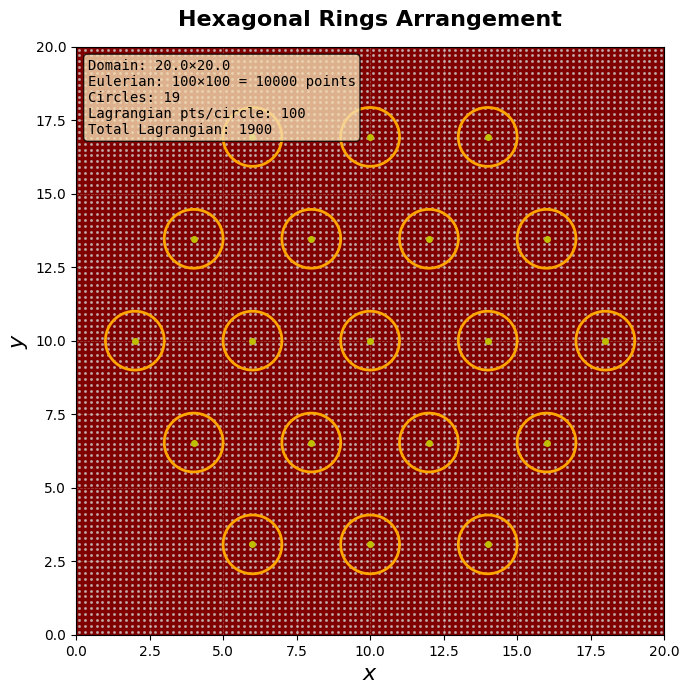


2. Square Lattice arrangement...
Saved: grid_plots/02_square_lattice.png


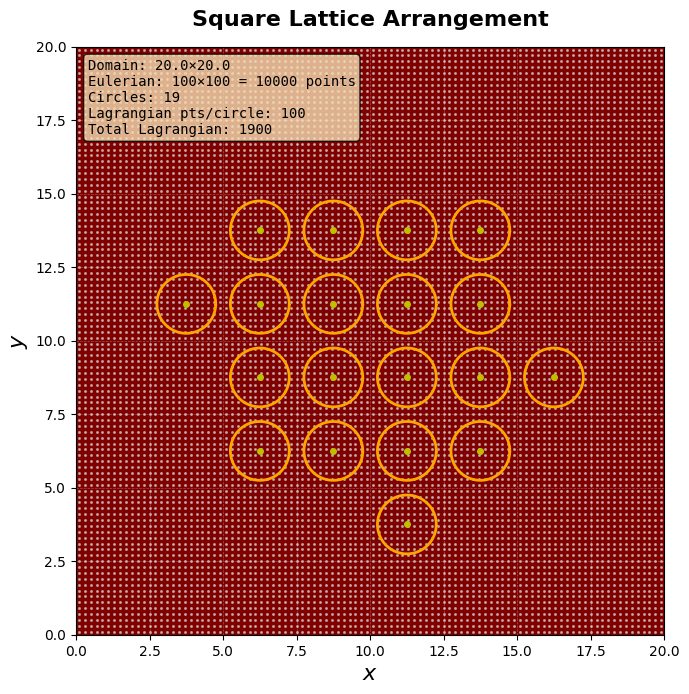


3. Polar/Radial arrangement...
Saved: grid_plots/04_polar_radial.png


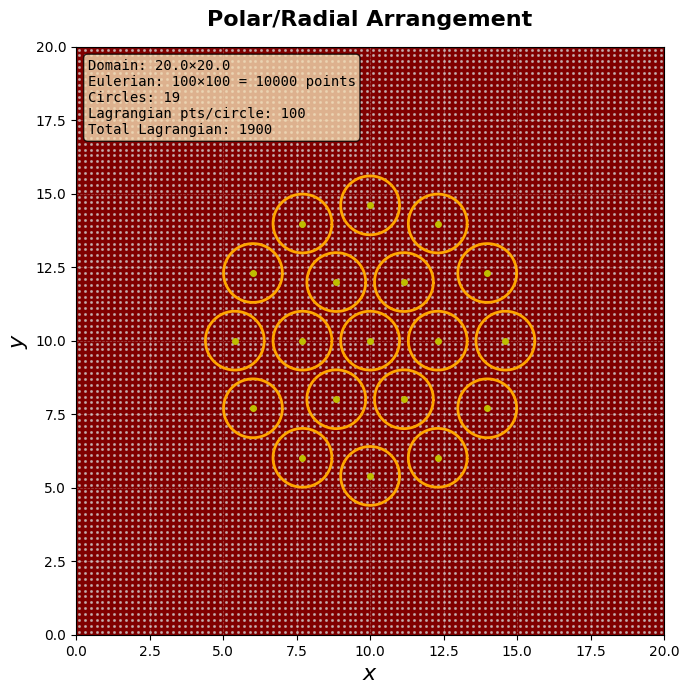


4. Random arrangement...
Saved: grid_plots/05_random.png


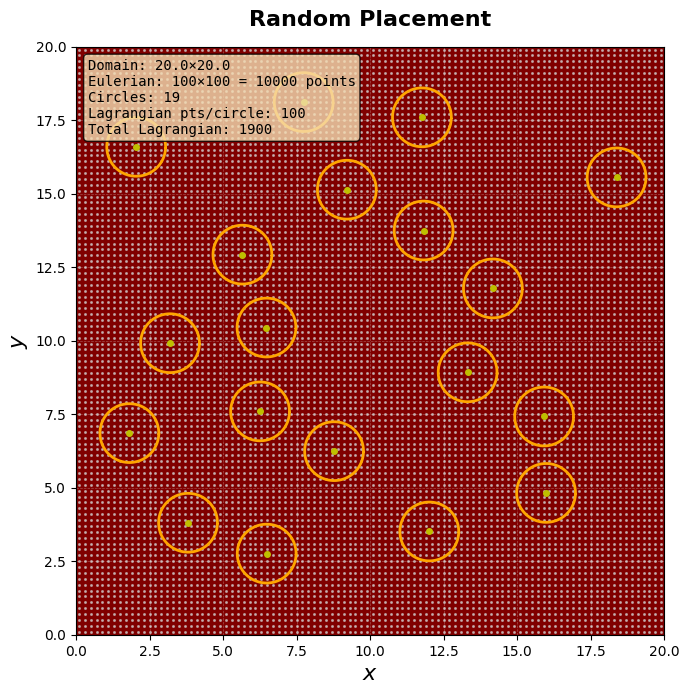

In [28]:
if __name__ == "__main__":
    
    Lx, Ly = 20.0, 20.0
    Nx, Ny = 100, 100
    Nk = 19
    M = 100
    r = 1.0
    
    grids = grids(Lx, Ly, Nx, Ny, Nk, M, r)